# DiffuseKronA Finetune + Inference Grid Experiments

Notebook ini menyiapkan workflow eksperimen untuk SD atau SDXL:

- memilih model family: `sd` atau `sdxl`
- mencoba beberapa subject, learning rate, jumlah gambar training, instance prompt, dan prompt inference
- training cukup sekali sampai `MAX_TRAIN_STEPS`, dengan checkpoint otomatis setiap `CHECKPOINTING_STEPS`
- inference mengambil checkpoint yang dipilih, misalnya `1000, 2000, 3000, 4000, 5000`
- hasil dirangkum menjadi grid: kolom pertama input subject + instance prompt, kolom berikutnya hasil checkpoint per step
- training time dan inference time dicatat otomatis ke CSV serta summary agregat untuk laporan

Struktur data yang diasumsikan sama seperti project ini: `../data/<subject>/input/` ketika notebook dijalankan dari folder `diffusekrona`.

## 1. Konfigurasi eksperimen

Ubah bagian ini sesuai subject dan prompt yang ingin dicoba. Biarkan `RUN_TRAINING=False` dan `RUN_INFERENCE=False` saat baru mengecek konfigurasi. Setelah plan sudah benar, ubah toggle yang dibutuhkan menjadi `True`.

In [ ]:
# Pilih salah satu: "sd" atau "sdxl"
MODEL_FAMILY = "sd"

# GPU yang akan dipakai. Sama seperti menjalankan: CUDA_VISIBLE_DEVICES=0 bash scripts/...
CUDA_VISIBLE_DEVICES = "0"

# Toggle eksekusi.
# RUN_TRAINING=False: cell training dilewati, cocok untuk cek konfigurasi atau inference dari checkpoint lama.
# RUN_TRAINING=True: notebook menjalankan accelerate launch untuk semua kombinasi subject/subset/lr.
RUN_TRAINING = True
RUN_INFERENCE = True
BUILD_GRIDS = True

# Jika checkpoint atau image hasil inference sudah ada, skip agar eksperimen bisa dilanjutkan.
SKIP_EXISTING_TRAINING = True
SKIP_EXISTING_INFERENCE = True

# Target jumlah gambar training. Notebook akan memilih yang valid sesuai jumlah data tersedia.
# Contoh: 1 gambar -> [1], 10 gambar -> [5, 10], 20 gambar -> [5, 10, 15].
SUBSET_SIZES = [5, 10, 15]

# Real configuration
LEARNING_RATES = [5e-4, 1e-3]
MAX_TRAIN_STEPS = 5000
CHECKPOINTING_STEPS = 1000
INFERENCE_CHECKPOINT_STEPS = [1000, 2000, 3000, 4000, 5000]

# # Testing configuration
# LEARNING_RATES = [5e-4, 1e-3]
# MAX_TRAIN_STEPS = 11
# CHECKPOINTING_STEPS = 5
# INFERENCE_CHECKPOINT_STEPS = [5,10]

SEED = 0

# Rank/adapter mengikuti script finetune bawaan.
ATTN_UPDATE_UNET = "kqvo"
A1 = 64
A2 = 8

# Nama run agar output notebook tidak bercampur dengan script manual.
RUN_NAME = "grid_experiments"

# Pilih subject yang aktif. Kosongkan [] untuk memakai semua key di SUBJECTS.
SELECTED_SUBJECTS = ["abiya", "TelkomUniversity", "HuggingFace"]

# Template prompt per kategori. Gunakan token unik subject di dalam prompt, misalnya sks_nama_subject.
PROMPT_TEMPLATES = {
    "face": [
        "A studio portrait of {token} person, soft light, sharp face details",
        "{token} person wearing an astronaut suit inside a spaceship",
        "{token} person standing under pink cherry blossoms",
        "{token} person in a cinematic cyberpunk city at night",
        "{token} person wearing a formal suit, professional headshot",
    ],
    "logo": [
        "A clean vector style {token} logo on a white background",
        "A metallic coin engraved with the {token} logo",
        "A neon sign showing the {token} logo on a dark storefront",
        "A minimal app icon based on the {token} logo",
        "A premium product package with the {token} logo printed on it",
    ],
    "object": [
        "A product photo of {token} object on a white studio background",
        "{token} object on a wooden table with natural window light",
        "{token} object in a futuristic showroom",
        "A macro close-up photo of {token} object",
        "{token} object in an outdoor lifestyle photography scene",
    ],
}

# Daftar subject. source_input_dir relatif terhadap folder diffusekrona.
# Isi subject baru di sini, lalu sesuaikan category, token, instance_prompt, dan prompt inference.
SUBJECTS = {
    "abiya": {
        "category": "face",
        "token": "sks abiya",
        "source_input_dir": "../data/abiya/input",
        "instance_prompt": "a photo of sks abiya person",
        "inference_prompts": [
            "A studio portrait photo of sks abiya person, soft light, sharp face details",
            "sks abiya person wearing an astronaut suit inside a spaceship",
            "sks abiya person standing under pink cherry blossoms, cinematic photography",
            "sks abiya person in a cyberpunk city at night, neon lighting",
            "sks abiya person wearing a formal suit, professional headshot",
        ],
    },
    "TelkomUniversity": {
        "category": "logo",
        "token": "sks telkom",
        "source_input_dir": "../data/TelkomUniversity/input",
        "instance_prompt": "a sks telkom logo",
        "inference_prompts": [
            "A clean vector style sks telkom logo on a white background",
            "A metallic coin engraved with the sks telkom logo",
            "A neon sign showing the sks telkom logo on a dark storefront",
            "A minimal mobile app icon based on the sks telkom logo",
            "A premium university merchandise package with the sks telkom logo printed on it",
        ],
    },
    "HuggingFace": {
        "category": "logo",
        "token": "sks huggingface",
        "source_input_dir": "../data/HuggingFace/input",
        "instance_prompt": "a sks huggingface logo",
        "inference_prompts": [
            "A clean vector style sks huggingface logo on a white background",
            "A metallic coin engraved with the sks huggingface logo",
            "A neon sign showing the sks huggingface logo on a dark storefront",
            "A minimal mobile app icon based on the sks huggingface logo",
            "A premium product package with the sks huggingface logo printed on it",
        ],
    },
}


## 2. Import dan deteksi path project

In [2]:
from pathlib import Path
from dataclasses import dataclass
import csv
import datetime as dt
import os
import re
import shutil
import subprocess
import textwrap
import time
from typing import Dict, Iterable, List, Optional

from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

RESAMPLE_LANCZOS = getattr(getattr(Image, "Resampling", Image), "LANCZOS")

PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / "train_dreambooth_lora.py").exists():
    candidate = PROJECT_DIR / "diffusekrona"
    if (candidate / "train_dreambooth_lora.py").exists():
        PROJECT_DIR = candidate.resolve()

assert (PROJECT_DIR / "train_dreambooth_lora.py").exists(), f"Tidak menemukan project diffusekrona dari {Path.cwd()}"
print(f"PROJECT_DIR = {PROJECT_DIR}")
print(f"MODEL_FAMILY = {MODEL_FAMILY}")


PROJECT_DIR = /workspace/FinalProject-GenAI/diffusekrona
MODEL_FAMILY = sd


## 3. Helper eksperimen

Cell ini membuat subset data, command training, command inference, path output yang konsisten dengan `struct_output()` di script training, serta helper pencatatan waktu eksperimen.

In [3]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

MODEL_CONFIG = {
    "sd": {
        "train_script": "train_dreambooth_lora.py",
        "inference_script": "inference_sd.py",
        "model_name": "Manojb/stable-diffusion-2-1-base",
        "resolution": 512,
        "diffusion_model": "base",
    },
    "sdxl": {
        "train_script": "train_dreambooth_lora_sdxl.py",
        "inference_script": "inference_sdxl.py",
        "model_name": "stabilityai/stable-diffusion-xl-base-1.0",
        "resolution": 1024,
        "diffusion_model": "sdxl",
    },
}

assert MODEL_FAMILY in MODEL_CONFIG, "MODEL_FAMILY harus 'sd' atau 'sdxl'"
CFG = MODEL_CONFIG[MODEL_FAMILY]

def slugify(value: str, max_len: int = 80) -> str:
    value = value.strip().lower()
    value = re.sub(r"[^a-z0-9._-]+", "_", value)
    value = re.sub(r"_+", "_", value).strip("_")
    return value[:max_len] or "item"

def lr_label(lr: float) -> str:
    # Harus mengikuti f-string float di struct_output(), misalnya 5e-4 -> 0.0005.
    return str(float(lr))

def exp_name(lr: float) -> str:
    attn_config = f"k{A1}:{A2}q{A1}:{A2}v{A1}:{A2}o{A1}:{A2}"
    return f"krona_{attn_config}_{CFG['diffusion_model']}_{lr_label(lr)}"

def active_subject_names() -> List[str]:
    names = SELECTED_SUBJECTS or list(SUBJECTS.keys())
    missing = [name for name in names if name not in SUBJECTS]
    assert not missing, f"Subject tidak ada di SUBJECTS: {missing}"
    return names

def source_images(subject_name: str) -> List[Path]:
    src_dir = (PROJECT_DIR / SUBJECTS[subject_name]["source_input_dir"]).resolve()
    if not src_dir.exists():
        return []
    return sorted([p for p in src_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS and p.is_file()])

def valid_subset_sizes(subject_name: str) -> List[int]:
    image_count = len(source_images(subject_name))
    if image_count <= 0:
        return []
    sizes = [size for size in SUBSET_SIZES if size <= image_count]
    return sizes or [image_count]

def prompts_for_subject(subject_name: str) -> List[str]:
    spec = SUBJECTS[subject_name]
    prompts = spec.get("inference_prompts")
    if prompts is None:
        prompts = PROMPT_TEMPLATES[spec["category"]]
    return [prompt.format(token=spec["token"], subject=subject_name) for prompt in prompts]

def subset_input_dir(subject_name: str, subset_size: int) -> Path:
    return (PROJECT_DIR / "../data/_notebook_subsets" / RUN_NAME / MODEL_FAMILY / f"{subject_name}_{subset_size}img" / "input").resolve()

def output_root(subject_name: str, subset_size: int) -> Path:
    return (PROJECT_DIR / "../outputs/_notebook_experiments" / RUN_NAME / MODEL_FAMILY / f"{subject_name}_{subset_size}img").resolve()

def train_output_dir(subject_name: str, subset_size: int, lr: float) -> Path:
    return output_root(subject_name, subset_size) / exp_name(lr)

def checkpoint_dir(subject_name: str, subset_size: int, lr: float, step: int) -> Path:
    return train_output_dir(subject_name, subset_size, lr) / f"checkpoint-{step}"

def inference_output_dir(subject_name: str, subset_size: int, lr: float, step: int, prompt_index: int) -> Path:
    return checkpoint_dir(subject_name, subset_size, lr, step) / "notebook_inference" / f"prompt_{prompt_index:02d}"

def inference_image_path(subject_name: str, subset_size: int, lr: float, step: int, prompt_index: int, seed: int = SEED) -> Path:
    return inference_output_dir(subject_name, subset_size, lr, step, prompt_index) / "images" / f"image_{seed}.jpg"

def prepare_subset(subject_name: str, subset_size: int, refresh: bool = True) -> Path:
    images = source_images(subject_name)
    if not images:
        raise ValueError(f"{subject_name}: tidak ada gambar di {SUBJECTS[subject_name]['source_input_dir']}")
    actual_size = min(subset_size, len(images))
    if actual_size != subset_size:
        print(f"{subject_name}: hanya ada {actual_size} gambar, memakai {actual_size} gambar.")
        subset_size = actual_size
    dst = subset_input_dir(subject_name, subset_size)
    if refresh and dst.exists():
        shutil.rmtree(dst)
    dst.mkdir(parents=True, exist_ok=True)
    for idx, src in enumerate(images[:subset_size], start=1):
        shutil.copy2(src, dst / f"{idx:03d}{src.suffix.lower()}")
    return dst

TIMING_RECORDS: List[Dict[str, object]] = []
TIMING_SUMMARY_DIR = (PROJECT_DIR / "../outputs/_notebook_timing" / RUN_NAME / MODEL_FAMILY).resolve()
TIMING_SUMMARY_CSV = TIMING_SUMMARY_DIR / "timing_records.csv"

def now_iso() -> str:
    return dt.datetime.now().isoformat(timespec="seconds")

def format_duration(seconds: float) -> str:
    seconds = float(seconds or 0.0)
    hours, remainder = divmod(int(round(seconds)), 3600)
    minutes, secs = divmod(remainder, 60)
    if hours:
        return f"{hours}h {minutes}m {secs}s"
    if minutes:
        return f"{minutes}m {secs}s"
    return f"{seconds:.2f}s"

def record_timing(stage: str, status: str, elapsed_seconds: float = 0.0, **metadata) -> Dict[str, object]:
    record = {
        "timestamp": now_iso(),
        "stage": stage,
        "status": status,
        "elapsed_seconds": round(float(elapsed_seconds or 0.0), 3),
        "elapsed_human": format_duration(elapsed_seconds),
        "model_family": MODEL_FAMILY,
        "run_name": RUN_NAME,
        **metadata,
    }
    TIMING_RECORDS.append(record)
    return record

def write_timing_records(path: Path = TIMING_SUMMARY_CSV) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = [
        "timestamp", "stage", "status", "elapsed_seconds", "elapsed_human",
        "model_family", "run_name", "subject", "subset_size", "learning_rate",
        "checkpoint_step", "prompt_index", "prompt", "output_path", "checkpoint_path", "note",
    ]
    extra_keys = sorted({key for record in TIMING_RECORDS for key in record.keys()} - set(fieldnames))
    with path.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames + extra_keys)
        writer.writeheader()
        for record in TIMING_RECORDS:
            writer.writerow(record)
    return path

def completed_records(stage: Optional[str] = None) -> List[Dict[str, object]]:
    return [
        record for record in TIMING_RECORDS
        if record.get("status") == "completed" and (stage is None or record.get("stage") == stage)
    ]

def summarize_completed(stage: str) -> Dict[str, object]:
    rows = completed_records(stage)
    total = sum(float(row["elapsed_seconds"]) for row in rows)
    return {
        "stage": stage,
        "completed_runs": len(rows),
        "total_seconds": round(total, 3),
        "total_human": format_duration(total),
        "average_seconds": round(total / len(rows), 3) if rows else 0.0,
        "average_human": format_duration(total / len(rows)) if rows else "0.00s",
    }

def print_timing_summary() -> None:
    summaries = [summarize_completed("training"), summarize_completed("inference")]
    print("\n=== Timing summary (completed runs only) ===")
    for item in summaries:
        print(
            f"{item['stage'].title()}: {item['completed_runs']} runs | "
            f"total {item['total_human']} | avg {item['average_human']}"
        )
    skipped = [record for record in TIMING_RECORDS if str(record.get("status", "")).startswith("skipped")]
    failed = [record for record in TIMING_RECORDS if record.get("status") == "failed"]
    if skipped:
        print(f"Skipped records: {len(skipped)}")
    if failed:
        print(f"Failed records: {len(failed)}")
    if TIMING_RECORDS:
        print(f"Timing CSV: {write_timing_records()}")
    else:
        print("Belum ada timing record. Jalankan cell training/inference terlebih dahulu.")

def run_command(cmd: List[str], cwd: Path = PROJECT_DIR) -> float:
    env = os.environ.copy()
    env["CUDA_VISIBLE_DEVICES"] = CUDA_VISIBLE_DEVICES
    print("CUDA_VISIBLE_DEVICES=", CUDA_VISIBLE_DEVICES)
    print(" ".join(str(part) for part in cmd))
    start = time.perf_counter()
    try:
        subprocess.run(cmd, cwd=str(cwd), env=env, check=True)
    finally:
        elapsed = time.perf_counter() - start
        print(f"Elapsed time: {format_duration(elapsed)} ({elapsed:.3f} seconds)")
    return elapsed

def train_command(subject_name: str, subset_size: int, lr: float) -> List[str]:
    subset_dir = subset_input_dir(subject_name, subset_size)
    out_root = output_root(subject_name, subset_size)
    out_root.mkdir(parents=True, exist_ok=True)
    # Trailing slash penting agar struct_output() tidak menambahkan nama folder input sebagai level output tambahan.
    instance_dir = str(subset_dir) + os.sep
    return [
        "accelerate", "launch", CFG["train_script"],
        "--pretrained_model_name_or_path", CFG["model_name"],
        "--instance_data_dir", instance_dir,
        "--output_dir", str(out_root),
        "--mixed_precision", "fp16",
        "--instance_prompt", SUBJECTS[subject_name]["instance_prompt"],
        "--resolution", str(CFG["resolution"]),
        "--train_batch_size", "1",
        "--gradient_accumulation_steps", "4",
        "--learning_rate", str(lr),
        "--lr_scheduler", "constant",
        "--lr_warmup_steps", "0",
        "--max_train_steps", str(MAX_TRAIN_STEPS),
        "--checkpointing_steps", str(CHECKPOINTING_STEPS),
        "--adapter_type", "krona",
        "--seed", str(SEED),
        "--diffusion_model", CFG["diffusion_model"],
        "--use_8bit_adam",
        "--gradient_checkpointing",
        "--attn_update_unet", ATTN_UPDATE_UNET,
        "--krona_unet_k_rank_a1", str(A1), "--krona_unet_k_rank_a2", str(A2),
        "--krona_unet_q_rank_a1", str(A1), "--krona_unet_q_rank_a2", str(A2),
        "--krona_unet_v_rank_a1", str(A1), "--krona_unet_v_rank_a2", str(A2),
        "--krona_unet_o_rank_a1", str(A1), "--krona_unet_o_rank_a2", str(A2),
    ]

def inference_command(subject_name: str, subset_size: int, lr: float, step: int, prompt_index: int, prompt: str) -> List[str]:
    ckpt = checkpoint_dir(subject_name, subset_size, lr, step)
    out = inference_output_dir(subject_name, subset_size, lr, step, prompt_index)
    out.mkdir(parents=True, exist_ok=True)
    return [
        "accelerate", "launch", CFG["inference_script"],
        "--checkpoint_path", str(ckpt),
        "--output_path", str(out),
        "--adapter_type", "krona",
        "--attn_update_unet", ATTN_UPDATE_UNET,
        "--prompt", prompt,
        "--seed", str(SEED),
    ]


## 4. Cek rencana eksperimen

Jalankan cell ini untuk melihat kombinasi yang akan dieksekusi dan memastikan folder data tersedia.

In [4]:

total_train_runs = 0
total_infer_runs = 0

for subject_name in active_subject_names():
    images = source_images(subject_name)
    subset_sizes = valid_subset_sizes(subject_name)
    prompts = prompts_for_subject(subject_name)
    print(f"\nSubject: {subject_name}")
    print(f"  source: {SUBJECTS[subject_name]['source_input_dir']} ({len(images)} images found)")
    print(f"  valid_subset_sizes: {subset_sizes if subset_sizes else 'SKIP - tidak ada gambar'}")
    print(f"  instance_prompt: {SUBJECTS[subject_name]['instance_prompt']}")
    print(f"  inference_prompts: {len(prompts)}")
    for i, prompt in enumerate(prompts):
        print(f"    [{i}] {prompt}")

    total_train_runs += len(subset_sizes) * len(LEARNING_RATES)
    total_infer_runs += len(subset_sizes) * len(LEARNING_RATES) * len(INFERENCE_CHECKPOINT_STEPS) * len(prompts)

print(f"\nTraining runs: {total_train_runs}")
print(f"Inference runs: {total_infer_runs}")
print("Grid rows per figure mengikuti valid_subset_sizes masing-masing subject.")
print(f"Grid checkpoint columns: {INFERENCE_CHECKPOINT_STEPS}")



Subject: abiya
  source: ../data/abiya/input (5 images found)
  valid_subset_sizes: [5]
  instance_prompt: a photo of sks abiya person
  inference_prompts: 5
    [0] A studio portrait photo of sks abiya person, soft light, sharp face details
    [1] sks abiya person wearing an astronaut suit inside a spaceship
    [2] sks abiya person standing under pink cherry blossoms, cinematic photography
    [3] sks abiya person in a cyberpunk city at night, neon lighting
    [4] sks abiya person wearing a formal suit, professional headshot

Subject: TelkomUniversity
  source: ../data/TelkomUniversity/input (1 images found)
  valid_subset_sizes: [1]
  instance_prompt: a sks telkom logo
  inference_prompts: 5
    [0] A clean vector style sks telkom logo on a white background
    [1] A metallic coin engraved with the sks telkom logo
    [2] A neon sign showing the sks telkom logo on a dark storefront
    [3] A minimal mobile app icon based on the sks telkom logo
    [4] A premium university merchan


## 5. Buat subset gambar adaptif

Subset dibuat di `../data/_notebook_subsets/...` sehingga data asli tidak diubah. Jika data kurang dari 5 gambar, notebook memakai semua gambar yang tersedia.


In [5]:

for subject_name in active_subject_names():
    subset_sizes = valid_subset_sizes(subject_name)
    if not subset_sizes:
        print(f"Skip {subject_name}: tidak ada gambar di {SUBJECTS[subject_name]['source_input_dir']}")
        continue
    for subset_size in subset_sizes:
        dst = prepare_subset(subject_name, subset_size, refresh=True)
        print(f"{subject_name} {subset_size} images -> {dst}")


abiya 5 images -> /workspace/FinalProject-GenAI/data/_notebook_subsets/grid_experiments/sd/abiya_5img/input
TelkomUniversity 1 images -> /workspace/FinalProject-GenAI/data/_notebook_subsets/grid_experiments/sd/TelkomUniversity_1img/input
HuggingFace 1 images -> /workspace/FinalProject-GenAI/data/_notebook_subsets/grid_experiments/sd/HuggingFace_1img/input


## 6. Jalankan training

Set `RUN_TRAINING=True` pada konfigurasi jika ingin menjalankan cell ini. Setiap kombinasi subject x subset size x learning rate dilatih sampai `MAX_TRAIN_STEPS`. Checkpoint akan tersimpan setiap `CHECKPOINTING_STEPS`.

In [6]:

if not RUN_TRAINING:
    print("RUN_TRAINING=False, training dilewati.")
else:
    for subject_name in active_subject_names():
        subset_sizes = valid_subset_sizes(subject_name)
        if not subset_sizes:
            print(f"Skip training {subject_name}: tidak ada gambar di {SUBJECTS[subject_name]['source_input_dir']}")
            record_timing(
                "training", "skipped_no_images", subject=subject_name,
                note=f"Tidak ada gambar di {SUBJECTS[subject_name]['source_input_dir']}",
            )
            continue
        for subset_size in subset_sizes:
            prepare_subset(subject_name, subset_size, refresh=False)
            for lr in LEARNING_RATES:
                final_ckpt = checkpoint_dir(subject_name, subset_size, lr, MAX_TRAIN_STEPS)
                common_meta = {
                    "subject": subject_name,
                    "subset_size": subset_size,
                    "learning_rate": lr_label(lr),
                    "checkpoint_step": MAX_TRAIN_STEPS,
                    "output_path": str(train_output_dir(subject_name, subset_size, lr)),
                    "checkpoint_path": str(final_ckpt),
                }
                if SKIP_EXISTING_TRAINING and final_ckpt.exists():
                    print(f"Skip training, checkpoint sudah ada: {final_ckpt}")
                    record_timing("training", "skipped_existing", **common_meta)
                    continue
                print(f"\n=== Training {MODEL_FAMILY} | {subject_name} | {subset_size} img | lr={lr} ===")
                try:
                    elapsed = run_command(train_command(subject_name, subset_size, lr))
                except Exception as exc:
                    record_timing("training", "failed", note=str(exc), **common_meta)
                    write_timing_records()
                    raise
                else:
                    record_timing("training", "completed", elapsed, **common_meta)
                    write_timing_records()

print_timing_summary()



=== Training sd | abiya | 5 img | lr=0.0005 ===
CUDA_VISIBLE_DEVICES= 0
accelerate launch train_dreambooth_lora.py --pretrained_model_name_or_path Manojb/stable-diffusion-2-1-base --instance_data_dir /workspace/FinalProject-GenAI/data/_notebook_subsets/grid_experiments/sd/abiya_5img/input/ --output_dir /workspace/FinalProject-GenAI/outputs/_notebook_experiments/grid_experiments/sd/abiya_5img --mixed_precision fp16 --instance_prompt a photo of sks abiya person --resolution 512 --train_batch_size 1 --gradient_accumulation_steps 4 --learning_rate 0.0005 --lr_scheduler constant --lr_warmup_steps 0 --max_train_steps 11 --checkpointing_steps 5 --adapter_type krona --seed 0 --diffusion_model base --use_8bit_adam --gradient_checkpointing --attn_update_unet kqvo --krona_unet_k_rank_a1 64 --krona_unet_k_rank_a2 8 --krona_unet_q_rank_a1 64 --krona_unet_q_rank_a2 8 --krona_unet_v_rank_a1 64 --krona_unet_v_rank_a2 8 --krona_unet_o_rank_a1 64 --krona_unet_o_rank_a2 8


The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.


output folder formatting done.


06/03/2026 21:21:38 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

You are using a model of type clip_text_model to instantiate a model of type . This is not supported for all configurations of models and can yield errors.
/workspace/FinalProject-GenAI/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
{'clip_sample_range', 'sample_max_value', 'thresholding', 'dynamic_thresholding_ratio', 'variance_type', 'timestep_spacing'} was not found in config. Values will be initialized to default values.
{'scaling_factor', 'force_upcast'} was not found in config. Values will be initialized to default values.
{'addition_embed_type_num_heads', 'class_

Elapsed time: 14.93s (14.934 seconds)

=== Training sd | abiya | 5 img | lr=0.001 ===
CUDA_VISIBLE_DEVICES= 0
accelerate launch train_dreambooth_lora.py --pretrained_model_name_or_path Manojb/stable-diffusion-2-1-base --instance_data_dir /workspace/FinalProject-GenAI/data/_notebook_subsets/grid_experiments/sd/abiya_5img/input/ --output_dir /workspace/FinalProject-GenAI/outputs/_notebook_experiments/grid_experiments/sd/abiya_5img --mixed_precision fp16 --instance_prompt a photo of sks abiya person --resolution 512 --train_batch_size 1 --gradient_accumulation_steps 4 --learning_rate 0.001 --lr_scheduler constant --lr_warmup_steps 0 --max_train_steps 11 --checkpointing_steps 5 --adapter_type krona --seed 0 --diffusion_model base --use_8bit_adam --gradient_checkpointing --attn_update_unet kqvo --krona_unet_k_rank_a1 64 --krona_unet_k_rank_a2 8 --krona_unet_q_rank_a1 64 --krona_unet_q_rank_a2 8 --krona_unet_v_rank_a1 64 --krona_unet_v_rank_a2 8 --krona_unet_o_rank_a1 64 --krona_unet_o_rank_

...

Elapsed time: 11.77s (11.769 seconds)

=== Training sd | HuggingFace | 1 img | lr=0.001 ===
CUDA_VISIBLE_DEVICES= 0
accelerate launch train_dreambooth_lora.py --pretrained_model_name_or_path Manojb/stable-diffusion-2-1-base --instance_data_dir /workspace/FinalProject-GenAI/data/_notebook_subsets/grid_experiments/sd/HuggingFace_1img/input/ --output_dir /workspace/FinalProject-GenAI/outputs/_notebook_experiments/grid_experiments/sd/HuggingFace_1img --mixed_precision fp16 --instance_prompt a sks huggingface logo --resolution 512 --train_batch_size 1 --gradient_accumulation_steps 4 --learning_rate 0.001 --lr_scheduler constant --lr_warmup_steps 0 --max_train_steps 11 --checkpointing_steps 5 --adapter_type krona --seed 0 --diffusion_model base --use_8bit_adam --gradient_checkpointing --attn_update_unet kqvo --krona_unet_k_rank_a1 64 --krona_unet_k_rank_a2 8 --krona_unet_q_rank_a1 64 --krona_unet_q_rank_a2 8 --krona_unet_v_rank_a1 64 --krona_unet_v_rank_a2 8 --krona_unet_o_rank_a1 64 --krona

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.


output folder formatting done.


06/03/2026 21:22:43 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

You are using a model of type clip_text_model to instantiate a model of type . This is not supported for all configurations of models and can yield errors.
/workspace/FinalProject-GenAI/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
{'variance_type', 'thresholding', 'dynamic_thresholding_ratio', 'sample_max_value', 'timestep_spacing', 'clip_sample_range'} was not found in config. Values will be initialized to default values.
{'force_upcast', 'scaling_factor'} was not found in config. Values will be initialized to default values.
{'cross_attention_norm', 'dropout', 'clas

Elapsed time: 11.66s (11.661 seconds)

=== Timing summary (completed runs only) ===
Training: 6 runs | total 1m 17s | avg 12.78s
Inference: 0 runs | total 0.00s | avg 0.00s
Timing CSV: /workspace/FinalProject-GenAI/outputs/_notebook_timing/grid_experiments/sd/timing_records.csv


## 7. Jalankan inference dari checkpoint

Set `RUN_INFERENCE=True` pada konfigurasi. Inference akan mengambil checkpoint di `INFERENCE_CHECKPOINT_STEPS` dan menyimpan output ke subfolder unik per prompt agar gambar tidak saling tertimpa.

In [7]:

if not RUN_INFERENCE:
    print("RUN_INFERENCE=False, inference dilewati.")
else:
    for subject_name in active_subject_names():
        prompts = prompts_for_subject(subject_name)
        subset_sizes = valid_subset_sizes(subject_name)
        if not subset_sizes:
            print(f"Skip inference {subject_name}: tidak ada gambar di {SUBJECTS[subject_name]['source_input_dir']}")
            record_timing(
                "inference", "skipped_no_images", subject=subject_name,
                note=f"Tidak ada gambar di {SUBJECTS[subject_name]['source_input_dir']}",
            )
            continue
        for subset_size in subset_sizes:
            for lr in LEARNING_RATES:
                for prompt_index, prompt in enumerate(prompts):
                    for step in INFERENCE_CHECKPOINT_STEPS:
                        ckpt = checkpoint_dir(subject_name, subset_size, lr, step)
                        image_path = inference_image_path(subject_name, subset_size, lr, step, prompt_index)
                        common_meta = {
                            "subject": subject_name,
                            "subset_size": subset_size,
                            "learning_rate": lr_label(lr),
                            "checkpoint_step": step,
                            "prompt_index": prompt_index,
                            "prompt": prompt,
                            "output_path": str(image_path),
                            "checkpoint_path": str(ckpt),
                        }
                        if not ckpt.exists():
                            print(f"Skip inference, checkpoint belum ada: {ckpt}")
                            record_timing("inference", "skipped_missing_checkpoint", **common_meta)
                            continue
                        if SKIP_EXISTING_INFERENCE and image_path.exists():
                            print(f"Skip inference, image sudah ada: {image_path}")
                            record_timing("inference", "skipped_existing", **common_meta)
                            continue
                        print(f"\n=== Inference {MODEL_FAMILY} | {subject_name} | {subset_size} img | lr={lr} | step={step} | prompt={prompt_index} ===")
                        try:
                            elapsed = run_command(inference_command(subject_name, subset_size, lr, step, prompt_index, prompt))
                        except Exception as exc:
                            record_timing("inference", "failed", note=str(exc), **common_meta)
                            write_timing_records()
                            raise
                        else:
                            record_timing("inference", "completed", elapsed, **common_meta)
                            write_timing_records()

print_timing_summary()



=== Inference sd | abiya | 5 img | lr=0.0005 | step=5 | prompt=0 ===
CUDA_VISIBLE_DEVICES= 0
accelerate launch inference_sd.py --checkpoint_path /workspace/FinalProject-GenAI/outputs/_notebook_experiments/grid_experiments/sd/abiya_5img/krona_k64:8q64:8v64:8o64:8_base_0.0005/checkpoint-5 --output_path /workspace/FinalProject-GenAI/outputs/_notebook_experiments/grid_experiments/sd/abiya_5img/krona_k64:8q64:8v64:8o64:8_base_0.0005/checkpoint-5/notebook_inference/prompt_00 --adapter_type krona --attn_update_unet kqvo --prompt A studio portrait photo of sks abiya person, soft light, sharp face details --seed 0


The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
/workspace/FinalProject-GenAI/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
100%|██████████| 50/50 [00:02<00:00, 18.99it/s]


Image generation completed.
Elapsed time: 9.89s (9.891 seconds)

=== Inference sd | abiya | 5 img | lr=0.0005 | step=10 | prompt=0 ===
CUDA_VISIBLE_DEVICES= 0
accelerate launch inference_sd.py --checkpoint_path /workspace/FinalProject-GenAI/outputs/_notebook_experiments/grid_experiments/sd/abiya_5img/krona_k64:8q64:8v64:8o64:8_base_0.0005/checkpoint-10 --output_path /workspace/FinalProject-GenAI/outputs/_notebook_experiments/grid_experiments/sd/abiya_5img/krona_k64:8q64:8v64:8o64:8_base_0.0005/checkpoint-10/notebook_inference/prompt_00 --adapter_type krona --attn_update_unet kqvo --prompt A studio portrait photo of sks abiya person, soft light, sharp face details --seed 0


The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
/workspace/FinalProject-GenAI/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
100%|██████████| 50/50 [00:02<00:00, 18.93it/s]


Image generation completed.
Elapsed time: 9.82s (9.819 seconds)

=== Inference sd | abiya | 5 img | lr=0.0005 | step=5 | prompt=1 ===
CUDA_VISIBLE_DEVICES= 0
accelerate launch inference_sd.py --checkpoint_path /workspace/FinalProject-GenAI/outputs/_notebook_experiments/grid_experiments/sd/abiya_5img/krona_k64:8q64:8v64:8o64:8_base_0.0005/checkpoint-5 --output_path /workspace/FinalProject-GenAI/outputs/_notebook_experiments/grid_experiments/sd/abiya_5img/krona_k64:8q64:8v64:8o64:8_base_0.0005/checkpoint-5/notebook_inference/prompt_01 --adapter_type krona --attn_update_unet kqvo --prompt sks abiya person wearing an astronaut suit inside a spaceship --seed 0


...

Image generation completed.
Elapsed time: 9.95s (9.954 seconds)

=== Inference sd | HuggingFace | 1 img | lr=0.001 | step=5 | prompt=4 ===
CUDA_VISIBLE_DEVICES= 0
accelerate launch inference_sd.py --checkpoint_path /workspace/FinalProject-GenAI/outputs/_notebook_experiments/grid_experiments/sd/HuggingFace_1img/krona_k64:8q64:8v64:8o64:8_base_0.001/checkpoint-5 --output_path /workspace/FinalProject-GenAI/outputs/_notebook_experiments/grid_experiments/sd/HuggingFace_1img/krona_k64:8q64:8v64:8o64:8_base_0.001/checkpoint-5/notebook_inference/prompt_04 --adapter_type krona --attn_update_unet kqvo --prompt A premium product package with the sks huggingface logo printed on it --seed 0


The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
/workspace/FinalProject-GenAI/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
100%|██████████| 50/50 [00:02<00:00, 19.01it/s]


Image generation completed.
Elapsed time: 9.82s (9.820 seconds)

=== Inference sd | HuggingFace | 1 img | lr=0.001 | step=10 | prompt=4 ===
CUDA_VISIBLE_DEVICES= 0
accelerate launch inference_sd.py --checkpoint_path /workspace/FinalProject-GenAI/outputs/_notebook_experiments/grid_experiments/sd/HuggingFace_1img/krona_k64:8q64:8v64:8o64:8_base_0.001/checkpoint-10 --output_path /workspace/FinalProject-GenAI/outputs/_notebook_experiments/grid_experiments/sd/HuggingFace_1img/krona_k64:8q64:8v64:8o64:8_base_0.001/checkpoint-10/notebook_inference/prompt_04 --adapter_type krona --attn_update_unet kqvo --prompt A premium product package with the sks huggingface logo printed on it --seed 0


The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
/workspace/FinalProject-GenAI/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
100%|██████████| 50/50 [00:02<00:00, 18.96it/s]


Image generation completed.
Elapsed time: 9.93s (9.930 seconds)

=== Timing summary (completed runs only) ===
Training: 6 runs | total 1m 17s | avg 12.78s
Inference: 60 runs | total 9m 54s | avg 9.90s
Timing CSV: /workspace/FinalProject-GenAI/outputs/_notebook_timing/grid_experiments/sd/timing_records.csv


## 8. Helper grid visualisasi

Grid dibuat per subject, per learning rate, dan per prompt inference. Baris adalah jumlah gambar training: 5, 10, 15. Kolom pertama adalah montage gambar input dan instance prompt. Kolom berikutnya adalah hasil inference dari checkpoint.

In [8]:
def load_font(size: int):
    candidates = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        "/usr/share/fonts/truetype/liberation2/LiberationSans-Regular.ttf",
    ]
    for path in candidates:
        if Path(path).exists():
            return ImageFont.truetype(path, size=size)
    return ImageFont.load_default()

FONT = load_font(22)
FONT_SMALL = load_font(18)
FONT_TITLE = load_font(28)

def wrap_text(text: str, width_chars: int) -> List[str]:
    lines = []
    for part in str(text).split("\n"):
        lines.extend(textwrap.wrap(part, width=width_chars) or [""])
    return lines

def draw_wrapped(draw: ImageDraw.ImageDraw, xy, text: str, font, fill, width_chars: int, line_height: int):
    x, y = xy
    for line in wrap_text(text, width_chars):
        draw.text((x, y), line, font=font, fill=fill)
        y += line_height
    return y

def fit_image(img: Image.Image, size=(320, 320), bg=(245, 245, 245)) -> Image.Image:
    img = img.convert("RGB")
    img.thumbnail(size, RESAMPLE_LANCZOS)
    canvas = Image.new("RGB", size, bg)
    x = (size[0] - img.width) // 2
    y = (size[1] - img.height) // 2
    canvas.paste(img, (x, y))
    return canvas

def placeholder(text: str, size=(320, 320)) -> Image.Image:
    canvas = Image.new("RGB", size, (238, 238, 238))
    draw = ImageDraw.Draw(canvas)
    y = 80
    for line in wrap_text(text, 24):
        draw.text((20, y), line, font=FONT_SMALL, fill=(80, 80, 80))
        y += 24
    return canvas

def input_montage(subject_name: str, subset_size: int, tile_size=96, cols=5) -> Image.Image:
    img_paths = sorted(subset_input_dir(subject_name, subset_size).glob("*"))
    img_paths = [p for p in img_paths if p.suffix.lower() in IMAGE_EXTENSIONS][:subset_size]
    rows = (len(img_paths) + cols - 1) // cols
    if rows == 0:
        return placeholder("input images not found")
    canvas = Image.new("RGB", (cols * tile_size, rows * tile_size), (250, 250, 250))
    for idx, path in enumerate(img_paths):
        try:
            tile = fit_image(Image.open(path), (tile_size, tile_size))
        except Exception as exc:
            tile = placeholder(str(exc), (tile_size, tile_size))
        x = (idx % cols) * tile_size
        y = (idx // cols) * tile_size
        canvas.paste(tile, (x, y))
    return fit_image(canvas, (320, 320), bg=(250, 250, 250))

def load_result_image(path: Path) -> Image.Image:
    if not path.exists():
        return placeholder(f"missing\n{path.name}\n{path.parent}")
    return fit_image(Image.open(path), (320, 320))

def make_grid(subject_name: str, lr: float, prompt_index: int) -> Path:
    prompt = prompts_for_subject(subject_name)[prompt_index]
    subset_sizes = valid_subset_sizes(subject_name)
    if not subset_sizes:
        raise ValueError(f"Tidak ada gambar untuk membuat grid subject {subject_name}")
    cell_w, cell_h = 360, 430
    header_h = 120
    cols = 1 + len(INFERENCE_CHECKPOINT_STEPS)
    rows = len(subset_sizes)
    width = cols * cell_w
    height = header_h + rows * cell_h
    canvas = Image.new("RGB", (width, height), (255, 255, 255))
    draw = ImageDraw.Draw(canvas)

    title = f"{MODEL_FAMILY.upper()} | {subject_name} | lr={lr_label(lr)} | prompt {prompt_index}"
    draw.text((20, 16), title, font=FONT_TITLE, fill=(20, 20, 20))
    draw_wrapped(draw, (20, 54), prompt, FONT_SMALL, (60, 60, 60), 145, 23)

    headers = ["Input + instance prompt"] + [f"checkpoint-{step}" for step in INFERENCE_CHECKPOINT_STEPS]
    for col, header in enumerate(headers):
        x = col * cell_w
        draw.rectangle([x, header_h - 34, x + cell_w, header_h], fill=(32, 32, 32))
        draw.text((x + 12, header_h - 28), header, font=FONT_SMALL, fill=(255, 255, 255))

    for row, subset_size in enumerate(subset_sizes):
        y0 = header_h + row * cell_h
        draw.rectangle([0, y0, width, y0 + cell_h], outline=(220, 220, 220), width=2)
        for col in range(cols):
            x0 = col * cell_w
            draw.rectangle([x0, y0, x0 + cell_w, y0 + cell_h], outline=(225, 225, 225), width=1)

        montage = input_montage(subject_name, subset_size)
        canvas.paste(montage, (20, y0 + 18))
        meta = f"{subset_size} training images\n{SUBJECTS[subject_name]['instance_prompt']}"
        draw_wrapped(draw, (18, y0 + 348), meta, FONT_SMALL, (30, 30, 30), 34, 22)

        for col, step in enumerate(INFERENCE_CHECKPOINT_STEPS, start=1):
            img = load_result_image(inference_image_path(subject_name, subset_size, lr, step, prompt_index))
            x = col * cell_w + 20
            canvas.paste(img, (x, y0 + 18))
            caption = f"{subset_size} img | step {step}"
            draw.text((x, y0 + 348), caption, font=FONT_SMALL, fill=(30, 30, 30))

    out_dir = PROJECT_DIR / "../outputs/_notebook_grids" / RUN_NAME / MODEL_FAMILY / subject_name / f"lr_{slugify(lr_label(lr))}"
    out_dir = out_dir.resolve()
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"prompt_{prompt_index:02d}.jpg"
    canvas.save(out_path, quality=95)
    return out_path


## 9. Buat dan tampilkan grid

/workspace/FinalProject-GenAI/outputs/_notebook_grids/grid_experiments/sd/abiya/lr_0.0005/prompt_00.jpg
/workspace/FinalProject-GenAI/outputs/_notebook_grids/grid_experiments/sd/abiya/lr_0.0005/prompt_01.jpg
/workspace/FinalProject-GenAI/outputs/_notebook_grids/grid_experiments/sd/abiya/lr_0.0005/prompt_02.jpg
/workspace/FinalProject-GenAI/outputs/_notebook_grids/grid_experiments/sd/abiya/lr_0.0005/prompt_03.jpg
/workspace/FinalProject-GenAI/outputs/_notebook_grids/grid_experiments/sd/abiya/lr_0.0005/prompt_04.jpg
/workspace/FinalProject-GenAI/outputs/_notebook_grids/grid_experiments/sd/abiya/lr_0.001/prompt_00.jpg
/workspace/FinalProject-GenAI/outputs/_notebook_grids/grid_experiments/sd/abiya/lr_0.001/prompt_01.jpg
/workspace/FinalProject-GenAI/outputs/_notebook_grids/grid_experiments/sd/abiya/lr_0.001/prompt_02.jpg
/workspace/FinalProject-GenAI/outputs/_notebook_grids/grid_experiments/sd/abiya/lr_0.001/prompt_03.jpg
/workspace/FinalProject-GenAI/outputs/_notebook_grids/grid_experimen

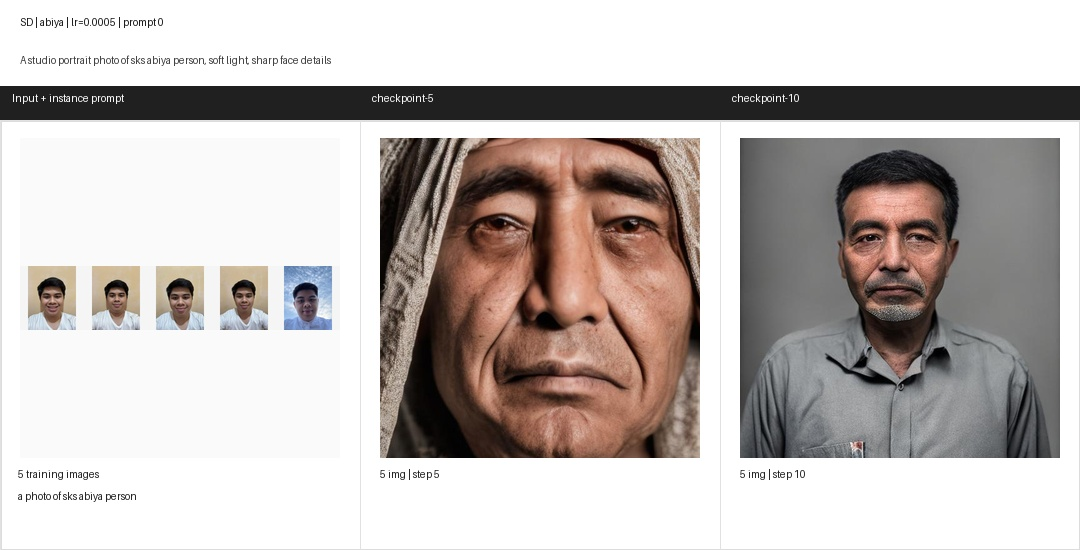

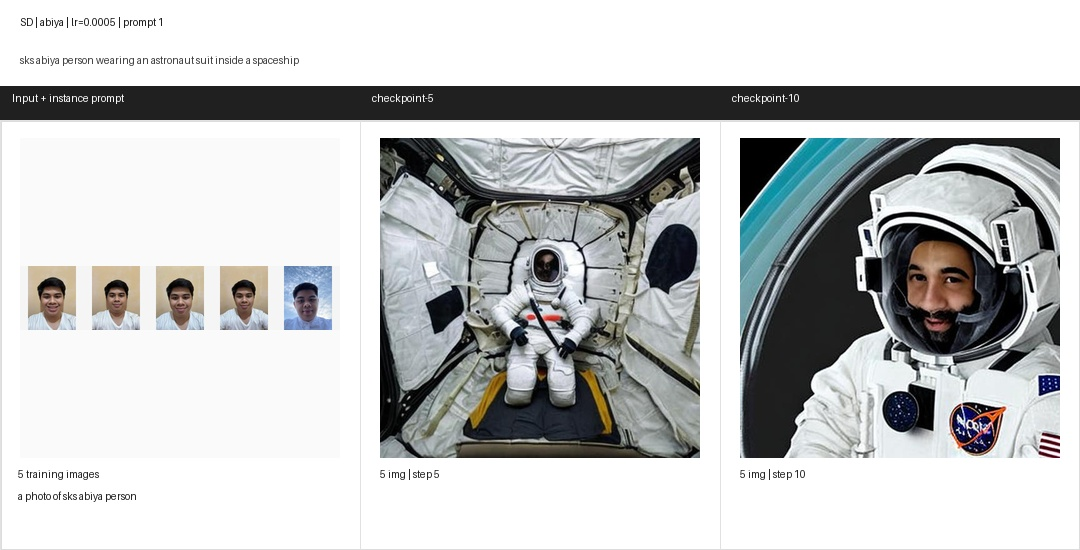

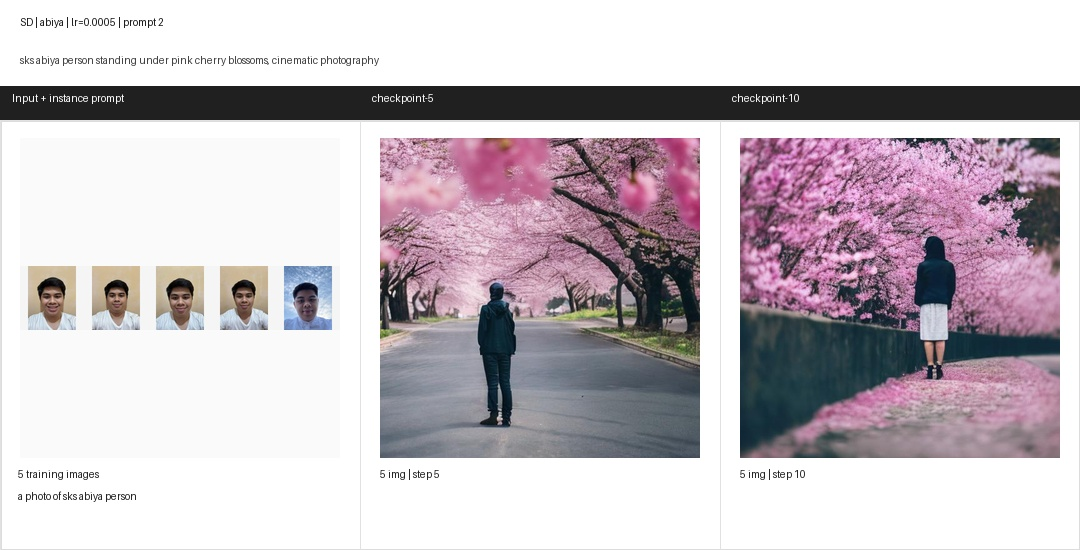

In [9]:

grid_paths = []
if not BUILD_GRIDS:
    print("BUILD_GRIDS=False, pembuatan grid dilewati.")
else:
    for subject_name in active_subject_names():
        if not valid_subset_sizes(subject_name):
            print(f"Skip grid {subject_name}: tidak ada gambar di {SUBJECTS[subject_name]['source_input_dir']}")
            continue
        for lr in LEARNING_RATES:
            for prompt_index, _prompt in enumerate(prompts_for_subject(subject_name)):
                path = make_grid(subject_name, lr, prompt_index)
                grid_paths.append(path)
                print(path)

print(f"Total grids: {len(grid_paths)}")
for path in grid_paths[:3]:
    display(Image.open(path))


## 10. Summary training time dan inference time

Cell ini menampilkan ringkasan durasi yang sudah dicatat selama cell training dan inference berjalan. CSV detail tersimpan di `../outputs/_notebook_timing/<RUN_NAME>/<MODEL_FAMILY>/timing_records.csv`.

In [10]:

print_timing_summary()

summary_rows = [summarize_completed("training"), summarize_completed("inference")]
try:
    import pandas as pd
    display(pd.DataFrame(summary_rows))
    if TIMING_RECORDS:
        display(pd.DataFrame(TIMING_RECORDS))
except ImportError:
    print(summary_rows)
    print(f"Total timing records: {len(TIMING_RECORDS)}")



=== Timing summary (completed runs only) ===
Training: 6 runs | total 1m 17s | avg 12.78s
Inference: 60 runs | total 9m 54s | avg 9.90s
Timing CSV: /workspace/FinalProject-GenAI/outputs/_notebook_timing/grid_experiments/sd/timing_records.csv


,stage,completed_runs,total_seconds,total_human,average_seconds,average_human
0,training,6,76.671,1m 17s,12.778,12.78s
1,inference,60,593.903,9m 54s,9.898,9.90s


,timestamp,stage,status,elapsed_seconds,elapsed_human,model_family,run_name,subject,subset_size,learning_rate,checkpoint_step,output_path,checkpoint_path,prompt_index,prompt
0,2026-06-03T21:21:50,training,completed,14.934,14.93s,sd,grid_experiments,abiya,5,0.0005,11,/workspace/FinalProject-GenAI/outputs/_noteboo...,/workspace/FinalProject-GenAI/outputs/_noteboo...,NaN,NaN
1,2026-06-03T21:22:05,training,completed,14.983,14.98s,sd,grid_experiments,abiya,5,0.001,11,/workspace/FinalProject-GenAI/outputs/_noteboo...,/workspace/FinalProject-GenAI/outputs/_noteboo...,NaN,NaN
2,2026-06-03T21:22:16,training,completed,11.688,11.69s,sd,grid_experiments,TelkomUniversity,1,0.0005,11,/workspace/FinalProject-GenAI/outputs/_noteboo...,/workspace/FinalProject-GenAI/outputs/_noteboo...,NaN,NaN
3,2026-06-03T21:22:28,training,completed,11.636,11.64s,sd,grid_experiments,TelkomUniversity,1,0.001,11,/workspace/FinalProject-GenAI/outputs/_noteboo...,/workspace/FinalProject-GenAI/outputs/_noteboo...,NaN,NaN
4,2026-06-03T21:22:40,training,completed,11.769,11.77s,sd,grid_experiments,HuggingFace,1,0.0005,11,/workspace/FinalProject-GenAI/outputs/_noteboo...,/workspace/FinalProject-GenAI/outputs/_noteboo...,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,2026-06-03T21:32:06,inference,completed,9.837,9.84s,sd,grid_experiments,HuggingFace,1,0.001,10,/workspace/FinalProject-GenAI/outputs/_noteboo...,/workspace/FinalProject-GenAI/outputs/_noteboo...,2.0,A neon sign showing the sks huggingface logo o...
62,2026-06-03T21:32:16,inference,completed,10.014,10.01s,sd,grid_experiments,HuggingFace,1,0.001,5,/workspace/FinalProject-GenAI/outputs/_noteboo...,/workspace/FinalProject-GenAI/outputs/_noteboo...,3.0,A minimal mobile app icon based on the sks hug...
63,2026-06-03T21:32:26,inference,completed,9.954,9.95s,sd,grid_experiments,HuggingFace,1,0.001,10,/workspace/FinalProject-GenAI/outputs/_noteboo...,/workspace/FinalProject-GenAI/outputs/_noteboo...,3.0,A minimal mobile app icon based on the sks hug...
64,2026-06-03T21:32:35,inference,completed,9.820,9.82s,sd,grid_experiments,HuggingFace,1,0.001,5,/workspace/FinalProject-GenAI/outputs/_noteboo...,/workspace/FinalProject-GenAI/outputs/_noteboo...,4.0,A premium product package with the sks hugging...


## Catatan praktis

- Untuk menjalankan hanya SDXL, ubah `MODEL_FAMILY = "sdxl"`.
- Untuk menjalankan hanya satu subject, isi `SELECTED_SUBJECTS = ["nama_subject"]`.
- Untuk prompt khusus subject, isi list `inference_prompts` di subject tersebut, bukan `None`.
- Training output ada di `../outputs/_notebook_experiments/<RUN_NAME>/<MODEL_FAMILY>/...`.
- Grid akhir ada di `../outputs/_notebook_grids/<RUN_NAME>/<MODEL_FAMILY>/...`.
- Detail waktu training dan inference ada di `../outputs/_notebook_timing/<RUN_NAME>/<MODEL_FAMILY>/timing_records.csv`.
- Script inference SD bawaan memakai nama file `image_<seed>.jpg`; notebook ini memberi folder output berbeda per prompt agar tidak overwrite.